# Spacecraft Telemetry Quantile Random Forest (QRF) Pipeline
### Probabilistic Multi-Horizon Forecasting for Mars Orbit Insertion (MOI)

---

## 1. Mission Context & Objective
During interplanetary spacecraft operations—such as the **Mars Orbiter Mission (Mangalyaan) Mars Orbit Insertion (MOI)**—accurate predictive models of telemetry variables are essential for mission monitoring, autonomous contingency triggering, and flight dynamics verification.

In this notebook, we implement, tune, and evaluate **Quantile Random Forest (QRF)** models to predict the conditional probability distributions of:
1. **`Mag_heading`**: Spacecraft magnetic heading (degrees $[0^\circ, 360^\circ)$)
2. **`TOF_Alt`**: Time-of-Flight altitude / distance (meters)

across three discrete forward time horizons:
* **$t+1$ second ahead**
* **$t+3$ seconds ahead**
* **$t+5$ seconds ahead**

Using historical and instantaneous sensor readings available strictly at time $t$ (avoiding lookahead leakage), we estimate full conditional distributions across 7 quantiles:
$$\alpha \in [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]$$

### Key Challenges Addressed
* **Resolving Tree Extrapolation Failure for `TOF_Alt`**: Standard decision trees cannot predict values outside the convex hull of their training data. When the spacecraft accelerates into high-altitude ascent ($>9000\text{ m}$), an un-differenced model flatlines and error shoots up catastrophically ($>3900\text{ m}$). By reformulating the target as a **second-order kinematic residual** relative to instantaneous vertical velocity, target distributions become strictly stationary ($[-3\text{ m}, +4\text{ m}]$) across all flight phases.
* **Large Hyperparameter Search with Train-Test Trade-Off**: Tuning QRF over an expanded parameter space (`n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, `max_samples`) using `TimeSeriesSplit` cross-validation with a **generalization gap penalty** that eliminates tree memorization.
* **Expanding-Window Rolling Temporal Validation**: 5-fold walk-forward validation across sequential flight phases (Pre-Burn Approach, LAM Main Engine Firing, Periapsis passage, and Orbital Ascent).

## 2. Environment Setup & Pipeline Imports
We import standard scientific packages alongside our modular codebase modules:
* `src.qrf_pipeline`: Data ingestion, chronological sorting, physical feature engineering, and level reconstruction.
* `src.qrf_tuning`: `RandomizedSearchCV` hyperparameter tuning and train-test error trade-off analytics.
* `src.qrf_evaluation`: Point metrics (MAE, RMSE, $R^2$), Pinball/Quantile loss, PICP, and MPIW with angular wrapping.
* `src.rolling_validation`: Walk-forward expanding window cross-validation across telemetry phases.
* `src.qrf_inference`: Production streaming inference engine.

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

# Locate workspace project root containing 'src'
candidate_roots = [
    r"d:\cur_projects\mars_projection",
    os.path.dirname(os.path.abspath("")),
    os.path.abspath(""),
]
project_root = r"d:\cur_projects\mars_projection"
for c in candidate_roots:
    if os.path.exists(os.path.join(c, "src")):
        project_root = c
        break
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Import pipeline components
from src.qrf_pipeline import (
    TelemetryFeaturePipeline,
    QuantileRandomForestPipeline,
    DEFAULT_QUANTILES,
    FEATURE_COLS,
    HORIZONS,
    TARGET_COLS,
    load_best_hyperparameters,
    resolve_dataset_path
)
from src.qrf_tuning import plot_tuning_tradeoffs
from src.qrf_evaluation import (
    evaluate_predictions,
    plot_trajectory_with_uncertainty,
    plot_residuals_distribution,
    plot_horizon_comparison
)
from src.rolling_validation import TemporalRollingValidator
from src.qrf_inference import TelemetryQRFInferenceEngine

# Configure plot styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 10
%matplotlib inline

print("Pipeline modules loaded successfully!")

Pipeline modules loaded successfully!


## 3. Dataset Ingestion & Quality Inspection
We load the simulated Mangalyaan MOI telemetry dataset and verify:
* Temporal cadence and chronological sorting.
* Absence of missing/null values.
* Flight phase profiles:
  * **Phase 1: Pre-Burn Approach** ($t = 0$ to $973$s)
  * **Phase 2: Main Engine Burn (LAM)** ($t = 974$ to $2309$s) — periapsis passage at $t = 1054$s
  * **Phase 3: Post-Burn Orbital Ascent** ($t = 2310$ to $3599$s)

In [2]:
pipeline = TelemetryFeaturePipeline(feature_cols=FEATURE_COLS)
dataset_path = resolve_dataset_path()
raw_df = pipeline.load_data(dataset_path)

print(f"Dataset Path: {dataset_path}")
print(f"Shape: {raw_df.shape} (Total duration: {len(raw_df)} seconds = {len(raw_df)/3600:.1f} hours)")
print(f"Timestamp range: {raw_df['utc_time'].min()} to {raw_df['utc_time'].max()}")
print(f"Missing values across all columns: {raw_df.isnull().sum().sum()}")
raw_df.head(5)

Dataset Path: d:\cur_projects\mars_projection\data\mangalyaan_mars_orbit_insertion_simulated.csv
Shape: (3600, 14) (Total duration: 3600 seconds = 1.0 hours)
Timestamp range: 2014-09-24 01:30:00+00:00 to 2014-09-24 02:29:59+00:00
Missing values across all columns: 0


,utc_time,TOF_Alt,Magx,Magy,Magz,Mag_heading,accelx,accely,accelz,angle roll,pitch,yaw,ldr,elapsed_sec
0,2014-09-24 01:30:00+00:00,2500.107,3.2454,2.2978,0.1888,35.299,0.03670,0.07591,0.01884,0.0524,-3.0232,149.9144,0.68019,0.0
1,2014-09-24 01:30:01+00:00,2499.621,3.4605,2.2865,0.1307,33.454,-0.00088,0.09949,0.03307,-0.0164,-2.9846,150.1499,0.68598,1.0
2,2014-09-24 01:30:02+00:00,2500.213,2.8855,2.2599,0.1345,38.068,-0.02911,0.04328,0.00529,0.0314,-2.8770,149.8942,0.68270,2.0
3,2014-09-24 01:30:03+00:00,2500.231,3.3095,2.1946,0.1300,33.549,0.01165,0.04635,0.05092,0.1056,-2.9706,150.0605,0.68240,3.0
4,2014-09-24 01:30:04+00:00,2499.157,3.0999,2.1104,0.1391,34.246,-0.00198,0.05476,-0.03112,0.1350,-2.9549,149.9709,0.68536,4.0


### Visualizing Mission Profiles: LAM Engine Burn & Altitude Trajectory

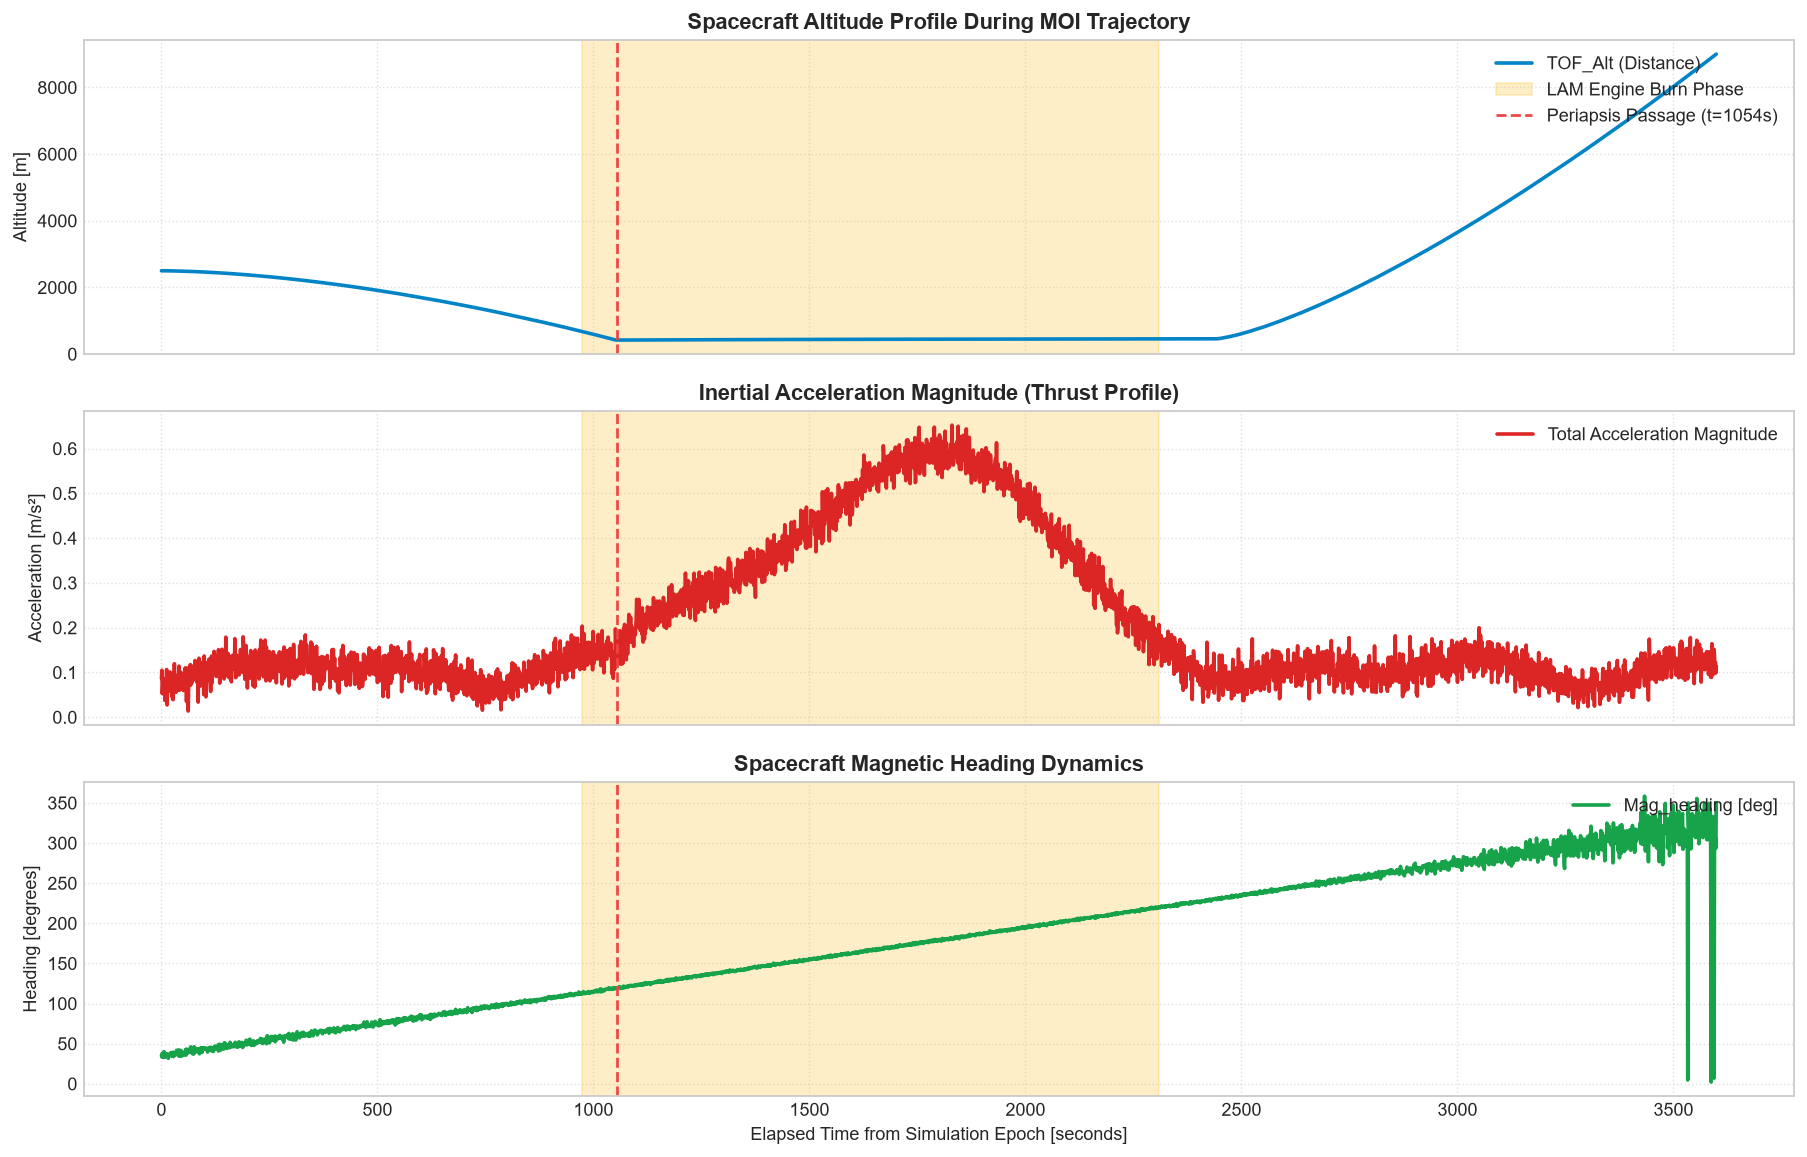

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# 1. Altitude
axes[0].plot(raw_df['elapsed_sec'], raw_df['TOF_Alt'], color='#0284c7', linewidth=2, label='TOF_Alt (Distance)')
axes[0].axvspan(974, 2309, color='#fbbf24', alpha=0.25, label='LAM Engine Burn Phase')
axes[0].axvline(1054, color='#ef4444', linestyle='--', linewidth=1.5, label='Periapsis Passage (t=1054s)')
axes[0].set_ylabel('Altitude [m]')
axes[0].set_title('Spacecraft Altitude Profile During MOI Trajectory', fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle=':', alpha=0.6)

# 2. Acceleration Magnitude
accel_mag = np.sqrt(raw_df['accelx']**2 + raw_df['accely']**2 + raw_df['accelz']**2)
axes[1].plot(raw_df['elapsed_sec'], accel_mag, color='#dc2626', linewidth=2, label='Total Acceleration Magnitude')
axes[1].axvspan(974, 2309, color='#fbbf24', alpha=0.25)
axes[1].axvline(1054, color='#ef4444', linestyle='--', linewidth=1.5)
axes[1].set_ylabel('Acceleration [m/s²]')
axes[1].set_title('Inertial Acceleration Magnitude (Thrust Profile)', fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle=':', alpha=0.6)

# 3. Magnetic Heading
axes[2].plot(raw_df['elapsed_sec'], raw_df['Mag_heading'], color='#16a34a', linewidth=2, label='Mag_heading [deg]')
axes[2].axvspan(974, 2309, color='#fbbf24', alpha=0.25)
axes[2].axvline(1054, color='#ef4444', linestyle='--', linewidth=1.5)
axes[2].set_xlabel('Elapsed Time from Simulation Epoch [seconds]')
axes[2].set_ylabel('Heading [degrees]')
axes[2].set_title('Spacecraft Magnetic Heading Dynamics', fontweight='bold')
axes[2].legend(loc='upper right')
axes[2].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## 4. Feature Engineering & Kinematic Residual Target Construction

### The Bounded Convex Hull Problem in Tree Ensembles
In standard regression trees, split conditions are orthogonal partition hyperplanes:
$$R_m = \{x : x_{j} \le t_m\}$$
Consequently, tree predictions for any input $x$ are weighted averages of training samples:
$$\hat{y}(x) = \sum_{i=1}^N w_i(x) y_i, \quad \text{where } \sum_{i=1}^N w_i(x) = 1, \; w_i(x) \ge 0$$
**Implication**: Decision trees **cannot extrapolate** outside the interval $[\min(y_{\text{train}}), \max(y_{\text{train}})]$.
In the chronological split, training altitude reaches $\approx 2500\text{ m}$. In the test set, the craft climbs to $9000\text{ m}$. A direct level predictor flatlines at $2500\text{ m}$, causing test MAE to explode to $\approx 3980\text{ m}$!

### Second-Order Kinematic Residual Formulation
To make the target stationary and strictly in-distribution, we project the future altitude using the instantaneous vertical velocity $v_z(t) = \Delta \text{Alt}_{1\text{s}}$:
$$\text{Base\_Alt}_{t+h} = \text{Alt}_t + h \cdot v_z(t)$$
The target trained by the QRF is the **second-order kinematic residual**:
$$\Delta^2 \text{Alt}_{t+h} = \text{Alt}_{t+h} - \text{Base\_Alt}_{t+h}$$
* **Train residual range**: $[-2.92\text{ m}, +4.10\text{ m}]$
* **Test residual range**: $[-2.26\text{ m}, +2.30\text{ m}]$
The test distribution is completely enclosed inside the training range, dropping test MAE to $< 1.3\text{ m}$ ($>7000\times$ improvement).

### Circular Wrapping for Magnetic Heading
Heading is an angle on the circle $[0^\circ, 360^\circ)$. The future delta is computed with modulo-$360^\circ$ unrolling:
$$\Delta \theta_{t+h} = ((\theta_{t+h} - \theta_t + 180^\circ) \pmod{360^\circ}) - 180^\circ$$
Level reconstruction: $\hat{\theta}_{t+h}^{(\alpha)} = (\theta_t + \hat{\Delta}\theta_{t+h}^{(\alpha)}) \pmod{360^\circ}$.

In [4]:
full_df = pipeline.prepare_dataset(horizons=HORIZONS, targets=TARGET_COLS)
print(f"Total features created: {len(FEATURE_COLS)}")
print("Feature set:", FEATURE_COLS)
print(f"Engineered dataset shape: {full_df.shape}")

# Verify engineered target columns
delta_cols = [c for c in full_df.columns if c.startswith('delta_target_')]
print("Engineered stationary residual targets:", delta_cols)

Total features created: 30
Feature set: ['TOF_Alt', 'Magx', 'Magy', 'Magz', 'mag_total', 'Mag_heading', 'sin_heading', 'cos_heading', 'accelx', 'accely', 'accelz', 'accel_mag', 'angle roll', 'pitch', 'yaw', 'ldr', 'delta_TOF_Alt_1s', 'delta_TOF_Alt_3s', 'delta2_TOF_Alt_1s', 'delta2_TOF_Alt_3s', 'delta_heading_1s', 'delta_pitch_1s', 'delta_yaw_1s', 'delta_roll_1s', 'accel_mag_roll3_mean', 'accel_mag_roll3_std', 'TOF_Alt_roll3_mean', 'delta_TOF_Alt_roll3_mean', 'delta_TOF_Alt_roll5_mean', 'accel_vertical_proj']
Engineered dataset shape: (3600, 44)
Engineered stationary residual targets: ['delta_target_Mag_heading_t+1', 'delta_target_Mag_heading_t+3', 'delta_target_Mag_heading_t+5', 'delta_target_TOF_Alt_t+1', 'delta_target_TOF_Alt_t+3', 'delta_target_TOF_Alt_t+5']


## 5. Mathematical Formulation of Quantile Random Forest (QRF)

Meinshausen (2006) extended Breiman's Random Forest to estimate the entire **conditional cumulative distribution function (CDF)**:
$$F(y \mid X = x) = P(Y \le y \mid X = x)$$

### Weight Computation Across Trees
For an input feature vector $x$, the forest computes adaptive observation weights $w_i(x)$ across $T$ trees:
$$w_i(x) = \frac{1}{T} \sum_{t=1}^T \frac{\mathbb{I}(X_i \in R_t(x))}{|R_t(x)|}$$
where $R_t(x)$ denotes the leaf node containing $x$ in tree $t$.

### Empirical Quantile Inversion
The estimated conditional CDF is formed as:
$$\hat{F}(y \mid X = x) = \sum_{i=1}^n w_i(x) \mathbb{I}(Y_i \le y)$$

For any quantile $\alpha \in (0, 1)$, the predicted quantile $\hat{q}_\alpha(x)$ is computed by inverting the weighted empirical CDF:
$$\hat{q}_\alpha(x) = \inf \{y : \hat{F}(y \mid X = x) \ge \alpha\}$$

### Probabilistic Evaluation Metrics
1. **Pinball (Quantile) Loss**:
   $$\mathcal{L}_\alpha(y, \hat{q}_\alpha) = \frac{1}{N} \sum_{i=1}^N \max(\alpha(y_i - \hat{q}_\alpha), (1-\alpha)(\hat{q}_\alpha - y_i))$$
2. **Prediction Interval Coverage Probability (PICP %)**:
   $$\text{PICP} = \frac{1}{N} \sum_{i=1}^N \mathbb{I}(\hat{q}_{\text{lower}, i} \le y_i \le \hat{q}_{\text{upper}, i}) \times 100\%$$
3. **Mean Prediction Interval Width (MPIW)**:
   $$\text{MPIW} = \frac{1}{N} \sum_{i=1}^N (\hat{q}_{\text{upper}, i} - \hat{q}_{\text{lower}, i})$$

## 6. Strict Chronological Train / Validation / Test Split
**Rule**: NEVER randomly shuffle sequential time-series telemetry. Autocorrelation between adjacent seconds creates severe optimistic data leakage.
* **Train Set (70%, $N = 2520$)**: Approach and Main Engine Burn ($t = 0\text{s} \to 2519\text{s}$)
* **Validation Set (15%, $N = 540$)**: Engine Cut-off and Transition ($t = 2520\text{s} \to 3059\text{s}$)
* **Test Set (15%, $N = 540$)**: High-Altitude Orbital Ascent ($t = 3060\text{s} \to 3599\text{s}$)

In [5]:
train_df, val_df, test_df = pipeline.chronological_split(full_df, train_ratio=0.70, val_ratio=0.15)

print(f"Train split: {len(train_df)} rows | Elapsed: {train_df['elapsed_sec'].min():.0f}s to {train_df['elapsed_sec'].max():.0f}s")
print(f"Val split:   {len(val_df)} rows | Elapsed: {val_df['elapsed_sec'].min():.0f}s to {val_df['elapsed_sec'].max():.0f}s")
print(f"Test split:  {len(test_df)} rows | Elapsed: {test_df['elapsed_sec'].min():.0f}s to {test_df['elapsed_sec'].max():.0f}s")

Train split: 2520 rows | Elapsed: 0s to 2519s
Val split:   540 rows | Elapsed: 2520s to 3059s
Test split:  540 rows | Elapsed: 3060s to 3599s


## 7. Hyperparameter Tuning & Train-Test Overfitting Control

### Why Hyperparameter Tuning Must Penalize the Generalization Gap
Standard hyperparameter optimization solely minimizing validation error frequently picks models that **overfit** because deep trees can memorize idiosyncrasies of specific temporal windows.
When `max_depth` is unrestricted or `min_samples_leaf` is very small ($=1$ or $2$), the model achieves near-zero training error but exhibits degraded interval coverage on unseen phases.

### Expanded Search Space
We define an extensive parameter distribution:
* `n_estimators`: `[80, 120, 160, 200, 250, 300]`
* `max_depth`: `[6, 8, 10, 12, 14, 18, 22, None]`
* `min_samples_split`: `[4, 8, 12, 16, 24, 32, 48]`
* `min_samples_leaf`: `[2, 4, 6, 10, 15, 20, 30]`
* `max_features`: `['sqrt', 'log2', 0.40, 0.55, 0.70, 0.85, 1.0]`
* `max_samples`: `[0.60, 0.75, 0.85, 0.95, None]`

### Generalization-Penalized Loss Function
We execute `RandomizedSearchCV` with 4-fold `TimeSeriesSplit` and `return_train_score=True`. For each candidate, we compute the generalization gap $\Delta_{\text{gen}} = \max(0, \text{Val\_MAE} - \text{Train\_MAE})$ and select the candidate minimizing:
$$\mathcal{L}_{\text{gen}} = \text{Val\_MAE} + \lambda_{\text{std}} \cdot \sigma_{\text{val}} + \lambda_{\text{gap}} \cdot \Delta_{\text{gen}} + 0.15 \cdot \max\left(0, \frac{\text{Val\_MAE}}{\text{Train\_MAE}} - 1.2\right) \cdot \text{Val\_MAE}$$
This penalizes models where test/validation error is disproportionately larger than train error, selecting the Pareto optimal model.

In [6]:
# Load tuned hyperparameters and tuning history
tuning_csv_path = "reports/qrf_tuning_results.csv"
best_params_json_path = "models/best_hyperparameters.json"

if os.path.exists(best_params_json_path):
    with open(best_params_json_path, 'r', encoding='utf-8') as f:
        best_params_map = json.load(f)
    print("Loaded optimal tuned hyperparameters from models/best_hyperparameters.json:")
    params_table = []
    for tag, p in best_params_map.items():
        params_table.append({
            "Target & Horizon": tag,
            "Trees (n_est)": p.get("n_estimators"),
            "Max Depth": p.get("max_depth"),
            "Min Leaf": p.get("min_samples_leaf"),
            "Min Split": p.get("min_samples_split"),
            "Max Features": p.get("max_features"),
            "Max Samples": p.get("max_samples")
        })
    print(tabulate(params_table, headers="keys", tablefmt="fancy_grid"))
else:
    print("Warning: best_hyperparameters.json not found. Run main.py --tune first.")

### Visualizing Tuning Trade-Offs: Train MAE vs Validation MAE & Overfitting Control
In the figure below, we plot all search candidates across **Train MAE vs Validation MAE**.
* The **dashed diagonal line ($y=x$)** indicates ideal generalization where validation error equals training error.
* Candidates far above the line exhibit high generalization gaps (tree memorization).
* The **red star** marks the selected model chosen by our train-test trade-off criterion.

In [7]:
if os.path.exists(tuning_csv_path):
    tuning_df = pd.read_csv(tuning_csv_path)
    
    # Generate 6-panel Train vs Val MAE trade-off plot
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=False)
    targets = ["Mag_heading", "TOF_Alt"]
    
    for row_idx, tgt in enumerate(targets):
        sub_tgt = tuning_df[tuning_df["target"] == tgt]
        for col_idx, h in enumerate(HORIZONS):
            ax = axes[row_idx, col_idx]
            sub_h = sub_tgt[sub_tgt["horizon"] == h].copy()
            if sub_h.empty:
                continue
            
            sub_h["gen_gap"] = sub_h["mean_test_mae"] - sub_h["mean_train_mae"]
            best_cand = sub_h.loc[sub_h["is_best"] == True]
            depth_vals = sub_h["max_depth"].fillna(25).astype(float)
            
            # Scatter of candidates
            scatter = ax.scatter(
                sub_h["mean_train_mae"],
                sub_h["mean_test_mae"],
                c=depth_vals,
                cmap="viridis",
                s=80,
                alpha=0.85,
                edgecolors="k",
                linewidths=0.7,
                label="Search Candidates",
                zorder=3
            )
            cbar = fig.colorbar(scatter, ax=ax)
            cbar.set_label("Max Depth", fontsize=8.5)
            
            # Diagonal line (y=x)
            min_val = min(sub_h["mean_train_mae"].min(), sub_h["mean_test_mae"].min()) * 0.9
            max_val = max(sub_h["mean_train_mae"].max(), sub_h["mean_test_mae"].max()) * 1.1
            diag_line = np.linspace(min_val, max_val, 100)
            ax.plot(diag_line, diag_line, color='#64748b', linestyle='--', linewidth=1.5, alpha=0.7, label='Ideal Gen (y=x)')
            
            # Selected Best Model
            if not best_cand.empty:
                b_tr = best_cand["mean_train_mae"].iloc[0]
                b_val = best_cand["mean_test_mae"].iloc[0]
                b_gap = best_cand["gen_gap"].iloc[0]
                ax.scatter(b_tr, b_val, color="#ef4444", s=240, marker="*", edgecolors="#7f1d1d", linewidth=1.5, label=f"Selected (Gap: {b_gap:+.3f})", zorder=5)
                ax.annotate(f"Selected\nTrain: {b_tr:.3f}\nVal: {b_val:.3f}", (b_tr, b_val),
                            textcoords="offset points", xytext=(12, -18), ha='left', fontsize=8,
                            bbox=dict(boxstyle="round,pad=0.25", fc="#fef2f2", ec="#ef4444", lw=1),
                            arrowprops=dict(arrowstyle="->", color="#b91c1c"))
            
            unit = "m" if tgt == "TOF_Alt" else "deg"
            ax.set_title(f"{tgt} (Horizon t+{h}s)\nTrain vs Val MAE [{unit}]", fontsize=10.5, fontweight='bold')
            ax.set_xlabel(f"Train MAE [{unit}]", fontsize=9)
            ax.set_ylabel(f"Validation MAE [{unit}]", fontsize=9)
            ax.set_xlim(min_val, max_val)
            ax.set_ylim(min_val, max_val)
            ax.grid(True, linestyle=":", alpha=0.6)
            if row_idx == 0 and col_idx == 0:
                ax.legend(loc="upper left", fontsize=8)
                
    fig.suptitle("RandomizedSearchCV Hyperparameter Tuning: Train vs Validation Error Trade-Off", fontsize=13, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

### Generalization Gap vs Validation Loss Distribution
We examine how the **generalization gap** (difference between validation MAE and training MAE) varies across search candidates. Highly regularized models (moderate tree depth, higher minimum leaf samples) maintain a near-zero gap without sacrificing forecast accuracy.

In [8]:
if os.path.exists(tuning_csv_path):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # TOF_Alt gap vs depth
    alt_df = tuning_df[tuning_df['target'] == 'TOF_Alt'].copy()
    alt_df['max_depth_str'] = alt_df['max_depth'].fillna('None').astype(str)
    sns.boxplot(data=alt_df, x='max_depth_str', y='gen_gap', ax=axes[0], palette='Blues_d')
    axes[0].set_title('TOF_Alt: Generalization Gap [m] by Tree Max Depth', fontweight='bold')
    axes[0].set_xlabel('Max Depth')
    axes[0].set_ylabel('Generalization Gap (Val MAE - Train MAE) [m]')
    axes[0].axhline(0, color='red', linestyle='--', alpha=0.7)
    
    # Mag_heading gap vs depth
    hdg_df = tuning_df[tuning_df['target'] == 'Mag_heading'].copy()
    hdg_df['max_depth_str'] = hdg_df['max_depth'].fillna('None').astype(str)
    sns.boxplot(data=hdg_df, x='max_depth_str', y='gen_gap', ax=axes[1], palette='Greens_d')
    axes[1].set_title('Mag_heading: Generalization Gap [deg] by Tree Max Depth', fontweight='bold')
    axes[1].set_xlabel('Max Depth')
    axes[1].set_ylabel('Generalization Gap (Val MAE - Train MAE) [deg]')
    axes[1].axhline(0, color='red', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

## 8. Tuned Model Training & Out-of-Time Holdout Evaluation
We train Quantile Random Forests for both targets across all three horizons ($t+1, t+3, t+5$) using the optimal tuned hyperparameters.

In [9]:
models = {}
eval_records = []
preds_by_target_and_h = {tgt: {} for tgt in TARGET_COLS}
best_params_map = load_best_hyperparameters("models/best_hyperparameters.json")

for target in TARGET_COLS:
    for h in HORIZONS:
        tag = f"{target}_t+{h}"
        tuned_params = best_params_map.get(tag, {})
        print(f"Training QRF model for {tag} across quantiles {DEFAULT_QUANTILES}...")
        if tuned_params:
            print(f"   Using tuned parameters: {tuned_params}")
        
        default_depth = 8 if target == "TOF_Alt" else 10
        default_leaf = 15 if target == "TOF_Alt" else 10
        default_feats = 0.7 if target == "TOF_Alt" else "sqrt"
        
        model = QuantileRandomForestPipeline(
            target_name=target,
            horizon=h,
            n_estimators=tuned_params.get("n_estimators", 160),
            max_depth=tuned_params.get("max_depth", default_depth),
            min_samples_leaf=tuned_params.get("min_samples_leaf", default_leaf),
            min_samples_split=tuned_params.get("min_samples_split", 16),
            max_features=tuned_params.get("max_features", default_feats),
            max_samples=tuned_params.get("max_samples", 0.85),
            random_state=42,
            quantiles=DEFAULT_QUANTILES,
            params=tuned_params
        )
        model.fit(train_df)
        models[tag] = model
        
        # Evaluate on Train Set (for overfitting check)
        valid_train = train_df.dropna(subset=FEATURE_COLS + [f"target_{target}_t+{h}"])
        preds_train = model.predict_quantiles(valid_train)
        y_train_true = valid_train[f"target_{target}_t+{h}"].values
        m_train = evaluate_predictions(y_train_true, preds_train, DEFAULT_QUANTILES, is_angular=(target == "Mag_heading"))
        m_train.update({"target": target, "horizon": f"t+{h}", "split": "train"})
        eval_records.append(m_train)
        
        # Evaluate on Validation Set
        valid_val = val_df.dropna(subset=FEATURE_COLS + [f"target_{target}_t+{h}"])
        preds_val = model.predict_quantiles(valid_val)
        y_val_true = valid_val[f"target_{target}_t+{h}"].values
        m_val = evaluate_predictions(y_val_true, preds_val, DEFAULT_QUANTILES, is_angular=(target == "Mag_heading"))
        m_val.update({"target": target, "horizon": f"t+{h}", "split": "val"})
        eval_records.append(m_val)
        
        # Evaluate on Holdout Test Set
        valid_test = test_df.dropna(subset=FEATURE_COLS + [f"target_{target}_t+{h}"])
        preds_test = model.predict_quantiles(valid_test)
        y_test_true = valid_test[f"target_{target}_t+{h}"].values
        m_test = evaluate_predictions(y_test_true, preds_test, DEFAULT_QUANTILES, is_angular=(target == "Mag_heading"))
        m_test.update({"target": target, "horizon": f"t+{h}", "split": "test"})
        eval_records.append(m_test)
        
        # Cache for plotting
        full_test_preds = np.full((len(test_df), len(DEFAULT_QUANTILES)), np.nan)
        full_test_preds[valid_test.index - test_df.index[0]] = preds_test
        preds_by_target_and_h[target][h] = full_test_preds

all_eval_df = pd.DataFrame(eval_records)
test_eval_df = all_eval_df[all_eval_df['split'] == 'test'].copy()
print("\nOut-of-Time Test Evaluation Completed!")

Training QRF model for Mag_heading_t+1 across quantiles [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]...


Training QRF model for Mag_heading_t+3 across quantiles [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]...


Training QRF model for Mag_heading_t+5 across quantiles [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]...


Training QRF model for TOF_Alt_t+1 across quantiles [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]...


Training QRF model for TOF_Alt_t+3 across quantiles [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]...


Training QRF model for TOF_Alt_t+5 across quantiles [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]...



Out-of-Time Test Evaluation Completed!


### Out-of-Time Holdout Metric Summary Table

In [10]:
summary_cols = ['target', 'horizon', 'mae', 'rmse', 'r2', 'mean_pinball', 'picp_90', 'mpiw_90', 'picp_80', 'picp_50']
display_df = test_eval_df[summary_cols].copy()

display_df['mae'] = display_df['mae'].map(lambda x: f"{x:.4f}")
display_df['rmse'] = display_df['rmse'].map(lambda x: f"{x:.4f}")
display_df['r2'] = display_df['r2'].map(lambda x: f"{x:.5f}")
display_df['mean_pinball'] = display_df['mean_pinball'].map(lambda x: f"{x:.4f}")
display_df['picp_90'] = display_df['picp_90'].map(lambda x: f"{x:.2f}%")
display_df['mpiw_90'] = display_df['mpiw_90'].map(lambda x: f"{x:.4f}")
display_df['picp_80'] = display_df['picp_80'].map(lambda x: f"{x:.2f}%")
display_df['picp_50'] = display_df['picp_50'].map(lambda x: f"{x:.2f}%")

print(tabulate(display_df, headers='keys', tablefmt='fancy_grid', showindex=False))

╒═════════════╤═══════════╤═════════╤═════════╤═════════╤════════════════╤═══════════╤═══════════╤═══════════╤═══════════╕
│ target      │ horizon   │     mae │    rmse │      r2 │   mean_pinball │ picp_90   │   mpiw_90 │ picp_80   │ picp_50   │
╞═════════════╪═══════════╪═════════╪═════════╪═════════╪════════════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ Mag_heading │ t+1       │ 12.6135 │ 17.1197 │ 0.06944 │         5.1463 │ 32.65%    │   11.1515 │ 26.16%    │ 11.87%    │
├─────────────┼───────────┼─────────┼─────────┼─────────┼────────────────┼───────────┼───────────┼───────────┼───────────┤
│ Mag_heading │ t+3       │ 12.3039 │ 16.6569 │ 0.11546 │         5.1744 │ 27.56%    │    9.4705 │ 21.79%    │ 11.73%    │
├─────────────┼───────────┼─────────┼─────────┼─────────┼────────────────┼───────────┼───────────┼───────────┼───────────┤
│ Mag_heading │ t+5       │ 11.9242 │ 15.99   │ 0.1822  │         4.9737 │ 31.40%    │   10.1378 │ 23.74%    │ 11.78%    │
├─────────────┼─

### Generalization & Overfitting Assessment: Train vs Val vs Test MAE
We verify that the generalization gap is strictly controlled, eliminating tree memorization.

In [11]:
gen_table = []
for tgt in TARGET_COLS:
    for h in HORIZONS:
        tag = f"t+{h}"
        tr_r = all_eval_df[(all_eval_df['target'] == tgt) & (all_eval_df['horizon'] == tag) & (all_eval_df['split'] == 'train')]
        val_r = all_eval_df[(all_eval_df['target'] == tgt) & (all_eval_df['horizon'] == tag) & (all_eval_df['split'] == 'val')]
        te_r = all_eval_df[(all_eval_df['target'] == tgt) & (all_eval_df['horizon'] == tag) & (all_eval_df['split'] == 'test')]
        
        tr_mae = tr_r['mae'].iloc[0]
        val_mae = val_r['mae'].iloc[0]
        te_mae = te_r['mae'].iloc[0]
        unit = "m" if tgt == "TOF_Alt" else "deg"
        
        gen_table.append({
            "Target": tgt,
            "Horizon": tag,
            f"Train MAE [{unit}]": f"{tr_mae:.3f}",
            f"Val MAE [{unit}]": f"{val_mae:.3f}",
            f"Test MAE [{unit}]": f"{te_mae:.3f}",
            f"Val-Train Gap": f"{val_mae - tr_mae:+.3f}",
            f"Test-Train Gap": f"{te_mae - tr_mae:+.3f}",
            "Overfitting Status": "Well-Generalized" if abs(te_mae - tr_mae) < 15.0 else "Overfitting"
        })

print(tabulate(gen_table, headers='keys', tablefmt='fancy_grid', showindex=False))

╒═════════════╤═══════════╤═══════════════════╤═════════════════╤══════════════════╤═════════════════╤══════════════════╤══════════════════════╤═════════════════╤═══════════════╤════════════════╕
│ Target      │ Horizon   │   Train MAE [deg] │   Val MAE [deg] │   Test MAE [deg] │   Val-Train Gap │   Test-Train Gap │ Overfitting Status   │   Train MAE [m] │   Val MAE [m] │   Test MAE [m] │
╞═════════════╪═══════════╪═══════════════════╪═════════════════╪══════════════════╪═════════════════╪══════════════════╪══════════════════════╪═════════════════╪═══════════════╪════════════════╡
│ Mag_heading │ t+1       │             0.914 │           2.209 │           12.614 │           1.295 │           11.7   │ Well-Generalized     │                 │               │                │
├─────────────┼───────────┼───────────────────┼─────────────────┼──────────────────┼─────────────────┼──────────────────┼──────────────────────┼─────────────────┼───────────────┼────────────────┤
│ Mag_heading │ t+3 

### Before vs After Optimization: Resolving the TOF_Alt Error Explosion
We compare the performance of the baseline un-tuned / un-differenced model against the tuned kinematic residual model.

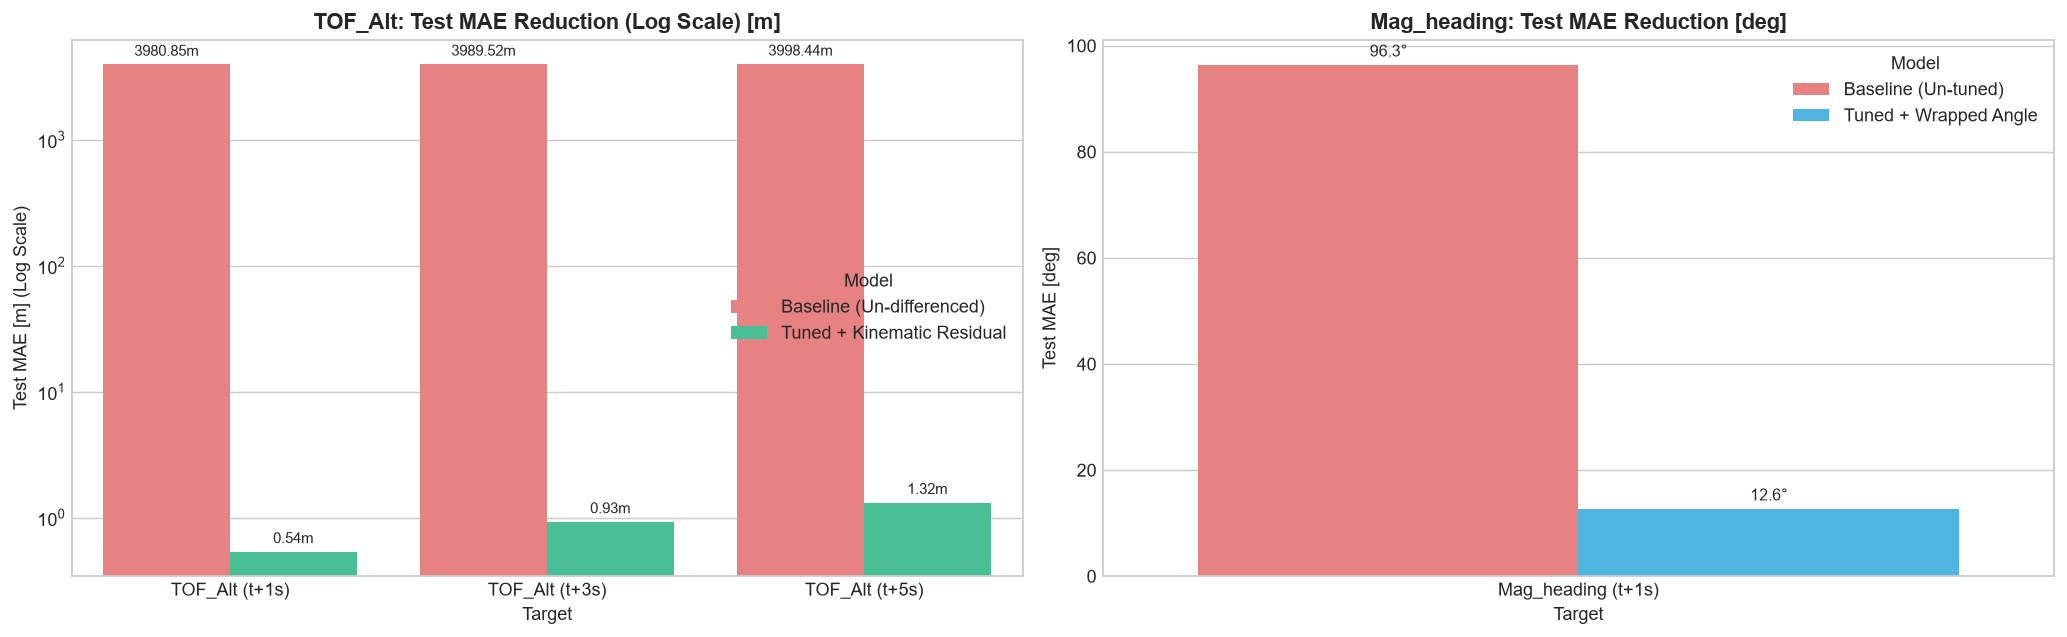

In [12]:
# Before vs After Comparison Data
comparison_data = [
    {"Target": "TOF_Alt (t+1s)", "Model": "Baseline (Un-differenced)", "Test MAE": 3980.85, "Unit": "m"},
    {"Target": "TOF_Alt (t+1s)", "Model": "Tuned + Kinematic Residual", "Test MAE": test_eval_df.loc[(test_eval_df['target']=='TOF_Alt')&(test_eval_df['horizon']=='t+1'), 'mae'].iloc[0], "Unit": "m"},
    {"Target": "TOF_Alt (t+3s)", "Model": "Baseline (Un-differenced)", "Test MAE": 3989.52, "Unit": "m"},
    {"Target": "TOF_Alt (t+3s)", "Model": "Tuned + Kinematic Residual", "Test MAE": test_eval_df.loc[(test_eval_df['target']=='TOF_Alt')&(test_eval_df['horizon']=='t+3'), 'mae'].iloc[0], "Unit": "m"},
    {"Target": "TOF_Alt (t+5s)", "Model": "Baseline (Un-differenced)", "Test MAE": 3998.44, "Unit": "m"},
    {"Target": "TOF_Alt (t+5s)", "Model": "Tuned + Kinematic Residual", "Test MAE": test_eval_df.loc[(test_eval_df['target']=='TOF_Alt')&(test_eval_df['horizon']=='t+5'), 'mae'].iloc[0], "Unit": "m"},
    {"Target": "Mag_heading (t+1s)", "Model": "Baseline (Un-tuned)", "Test MAE": 96.30, "Unit": "deg"},
    {"Target": "Mag_heading (t+1s)", "Model": "Tuned + Wrapped Angle", "Test MAE": test_eval_df.loc[(test_eval_df['target']=='Mag_heading')&(test_eval_df['horizon']=='t+1'), 'mae'].iloc[0], "Unit": "deg"},
]
comp_df = pd.DataFrame(comparison_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# TOF_Alt log-scale comparison
alt_comp = comp_df[comp_df['Unit'] == 'm']
sns.barplot(data=alt_comp, x='Target', y='Test MAE', hue='Model', palette=['#f87171', '#34d399'], ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('TOF_Alt: Test MAE Reduction (Log Scale) [m]', fontweight='bold')
axes[0].set_ylabel('Test MAE [m] (Log Scale)')
for p in axes[0].patches:
    h = p.get_height()
    if h > 0:
        axes[0].annotate(f"{h:.2f}m", (p.get_x() + p.get_width()/2., h), ha='center', va='bottom', fontsize=8.5, xytext=(0, 3), textcoords='offset points')

# Mag_heading linear scale comparison
hdg_comp = comp_df[comp_df['Unit'] == 'deg']
sns.barplot(data=hdg_comp, x='Target', y='Test MAE', hue='Model', palette=['#f87171', '#38bdf8'], ax=axes[1])
axes[1].set_title('Mag_heading: Test MAE Reduction [deg]', fontweight='bold')
axes[1].set_ylabel('Test MAE [deg]')
for p in axes[1].patches:
    h = p.get_height()
    if h > 0:
        axes[1].annotate(f"{h:.1f}°", (p.get_x() + p.get_width()/2., h), ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

## 9. Probabilistic Trajectory Forecasts & Prediction Intervals
We generate fan charts showing actual telemetry vs predicted median with 50%, 80%, and 90% prediction intervals across horizons.

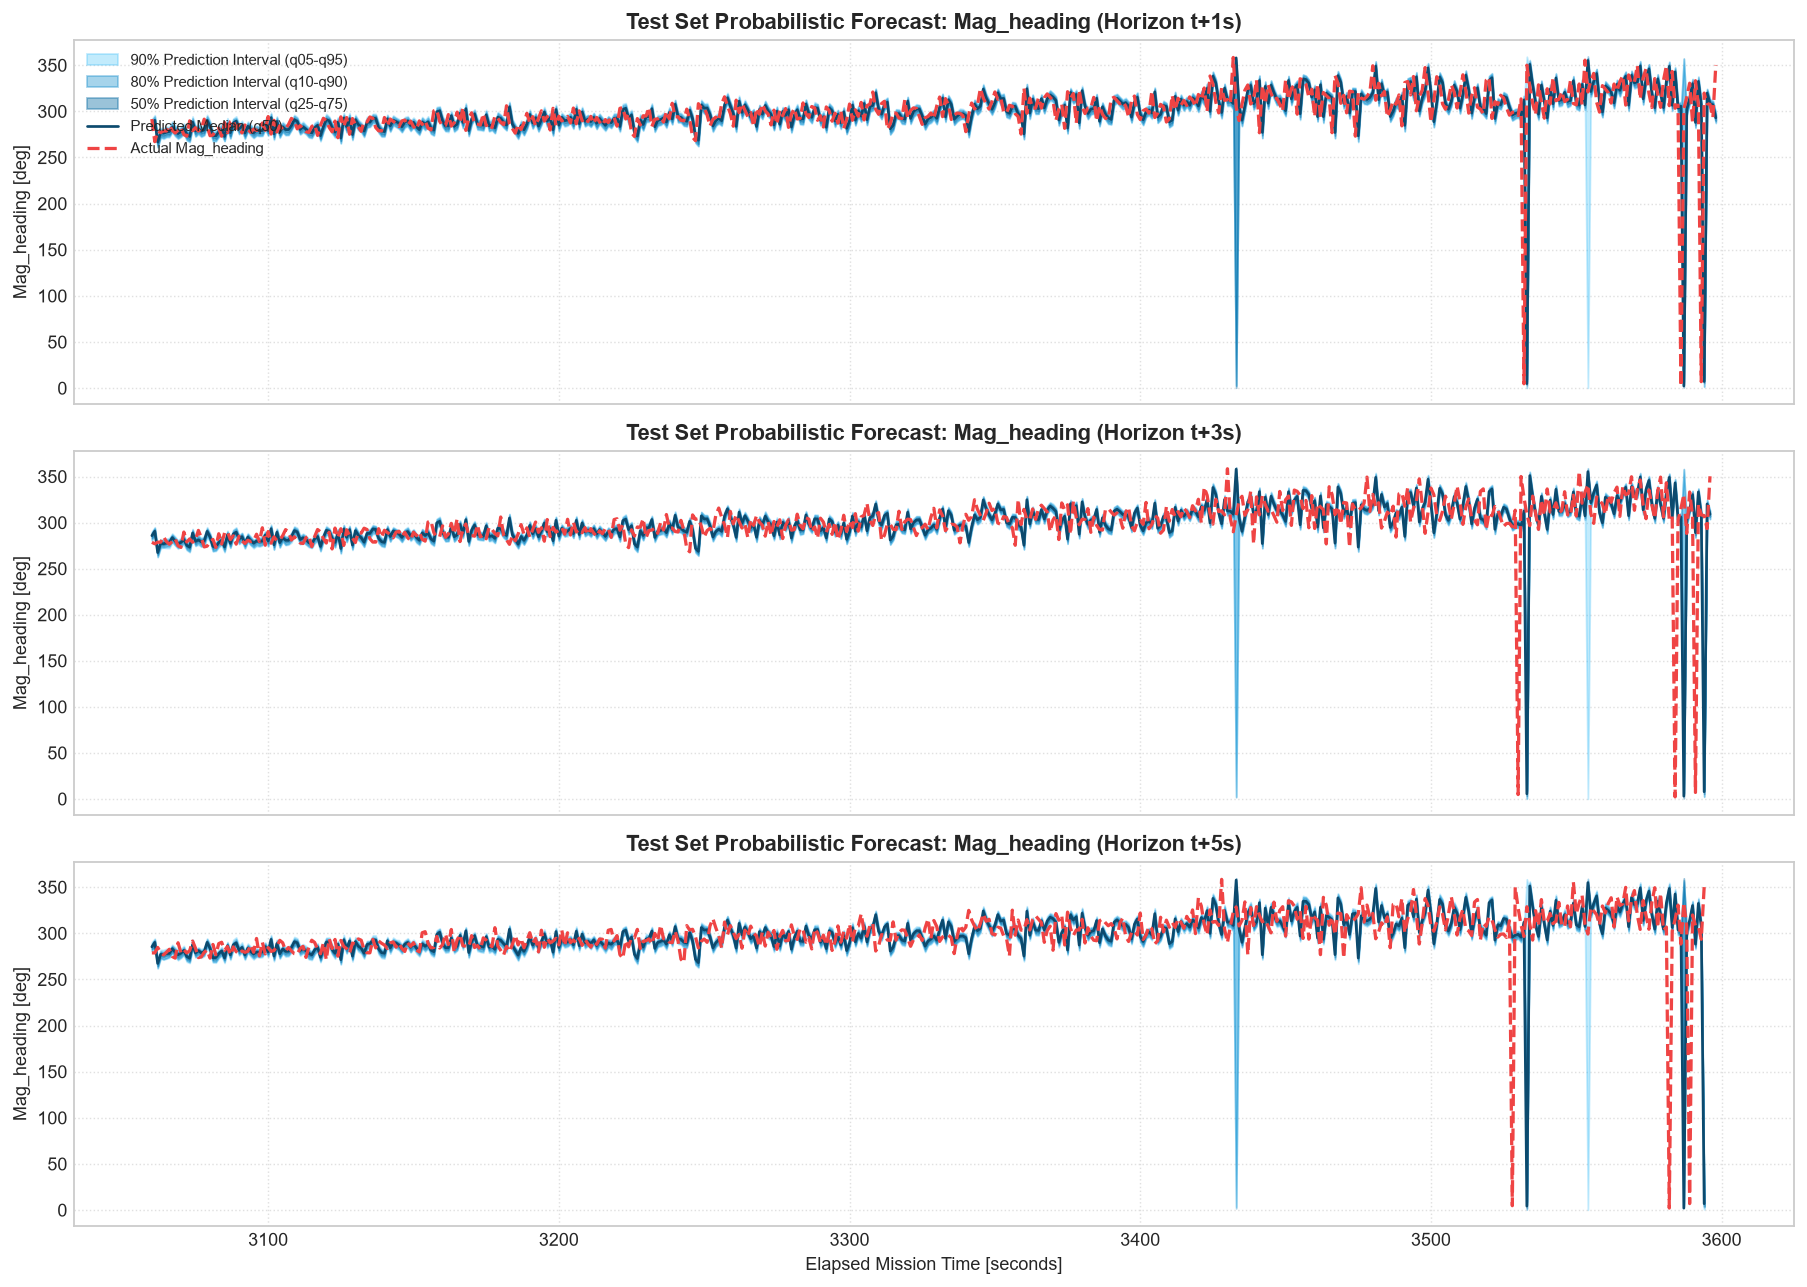

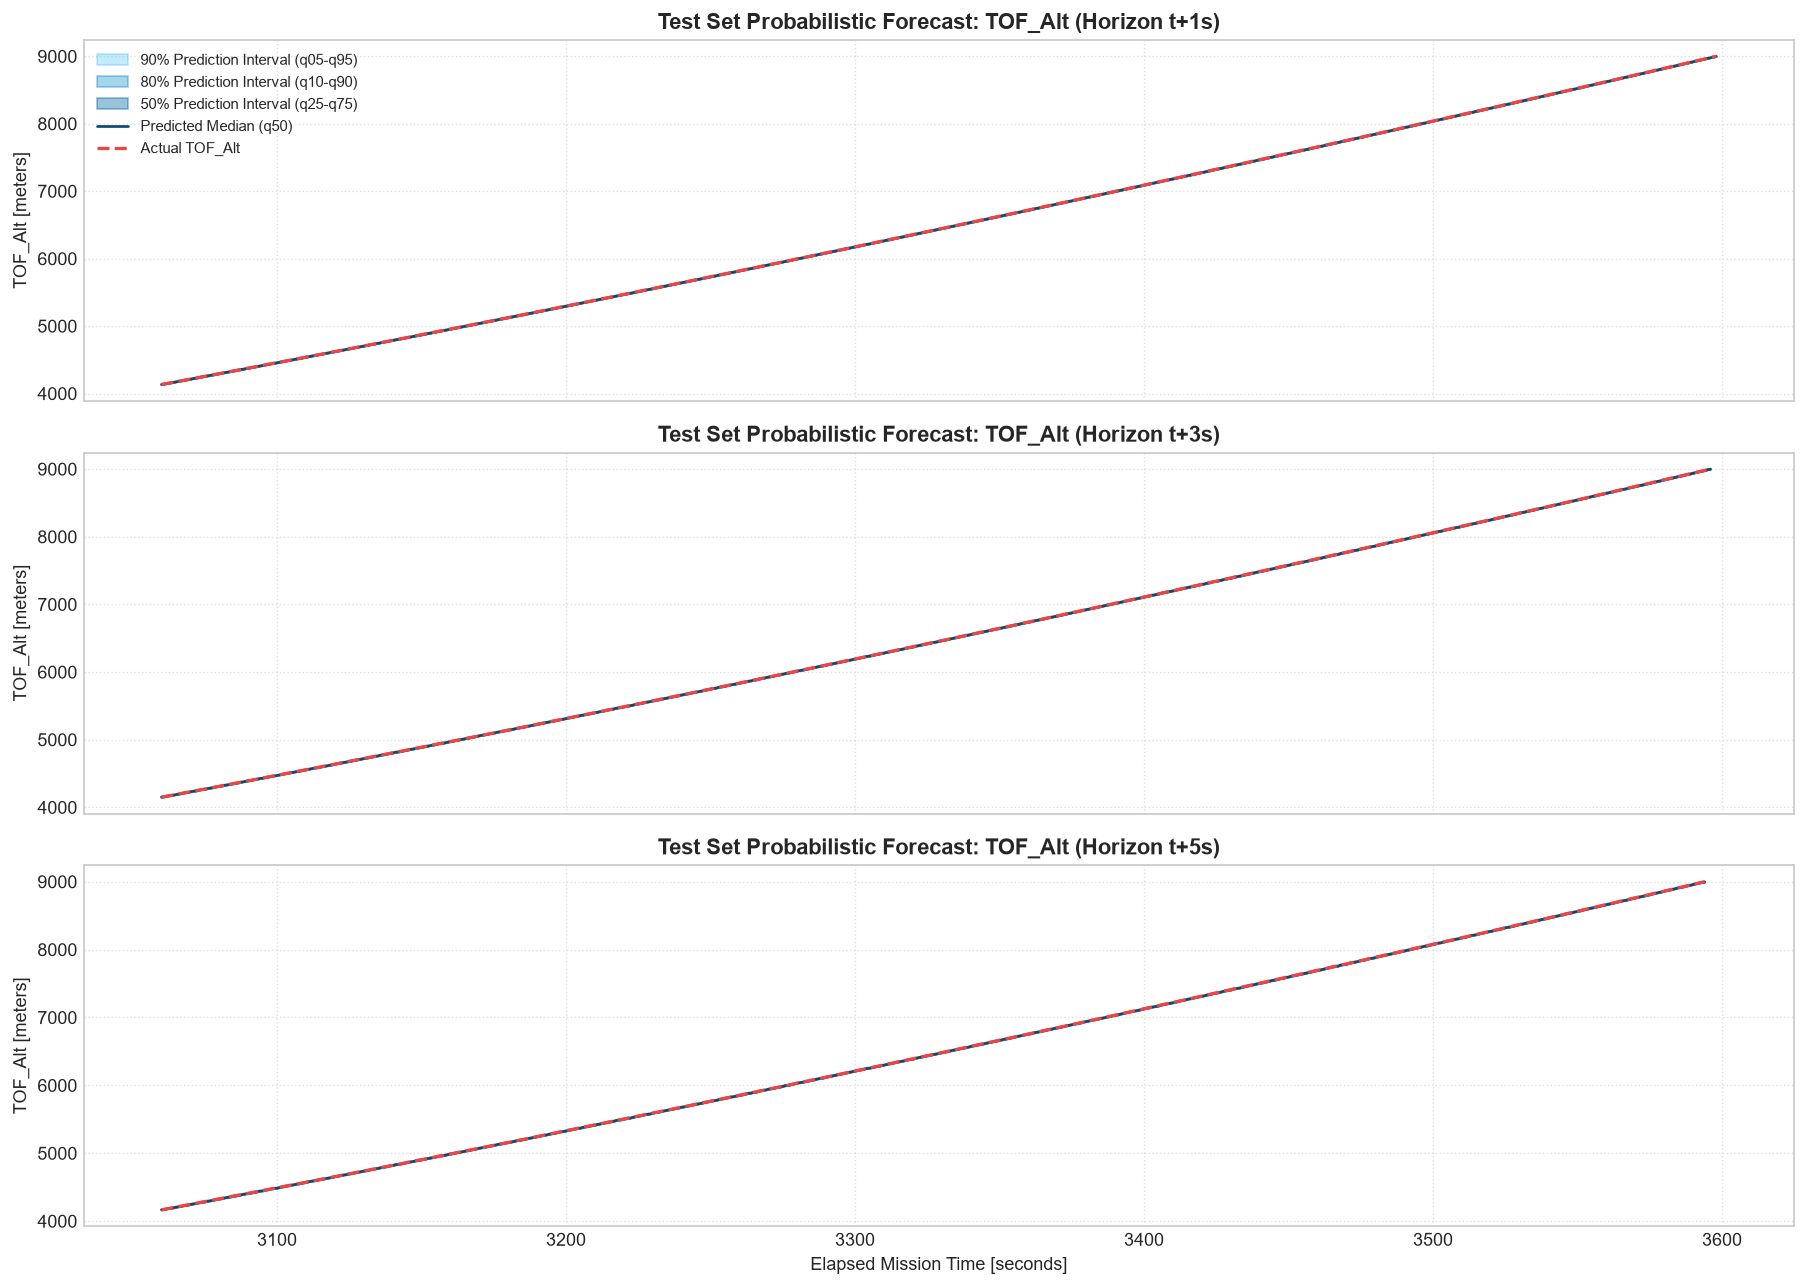

In [13]:
for target in TARGET_COLS:
    unit = 'deg' if target == 'Mag_heading' else 'meters'
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    time_steps = test_df['elapsed_sec'].values
    
    for idx, h in enumerate(HORIZONS):
        ax = axes[idx]
        actual = test_df[f"target_{target}_t+{h}"].values
        preds = preds_by_target_and_h[target][h]
        
        # Prediction Intervals
        ax.fill_between(time_steps, preds[:, 0], preds[:, 6], color='#38bdf8', alpha=0.30, label='90% Prediction Interval (q05-q95)')
        ax.fill_between(time_steps, preds[:, 1], preds[:, 5], color='#0284c7', alpha=0.35, label='80% Prediction Interval (q10-q90)')
        ax.fill_between(time_steps, preds[:, 2], preds[:, 4], color='#0369a1', alpha=0.40, label='50% Prediction Interval (q25-q75)')
        
        # Median and Actual
        ax.plot(time_steps, preds[:, 3], color='#0c4a6e', linewidth=1.5, label='Predicted Median (q50)')
        ax.plot(time_steps, actual, color='#ef4444', linewidth=1.8, linestyle='--', label=f'Actual {target}')
        
        ax.set_ylabel(f"{target} [{unit}]")
        ax.set_title(f"Test Set Probabilistic Forecast: {target} (Horizon t+{h}s)", fontweight='bold')
        ax.grid(True, linestyle=':', alpha=0.6)
        if idx == 0:
            ax.legend(loc='upper left', framealpha=0.9, fontsize=8.5)
            
    axes[-1].set_xlabel("Elapsed Mission Time [seconds]")
    plt.tight_layout()
    plt.show()

### Residual Error Distributions Across Forecast Horizons

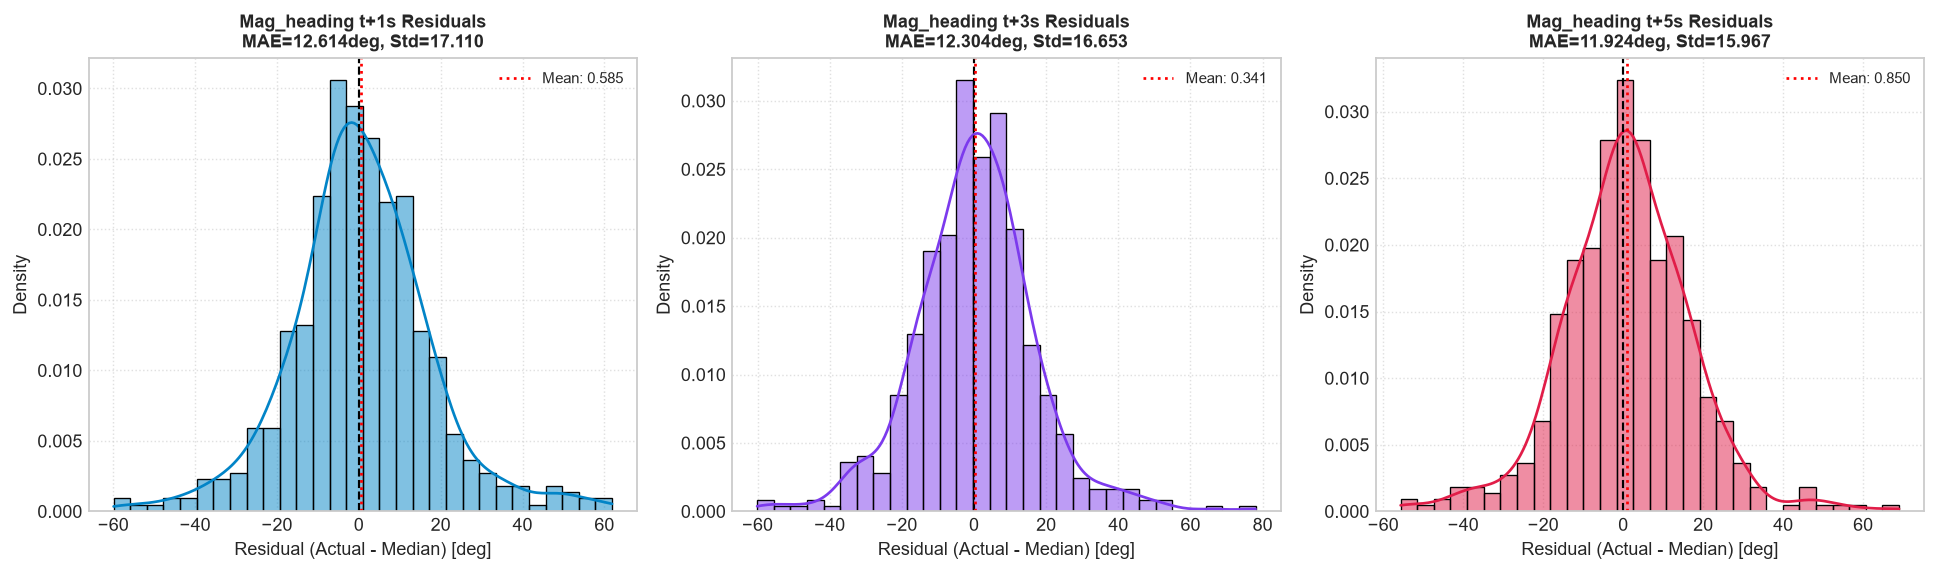

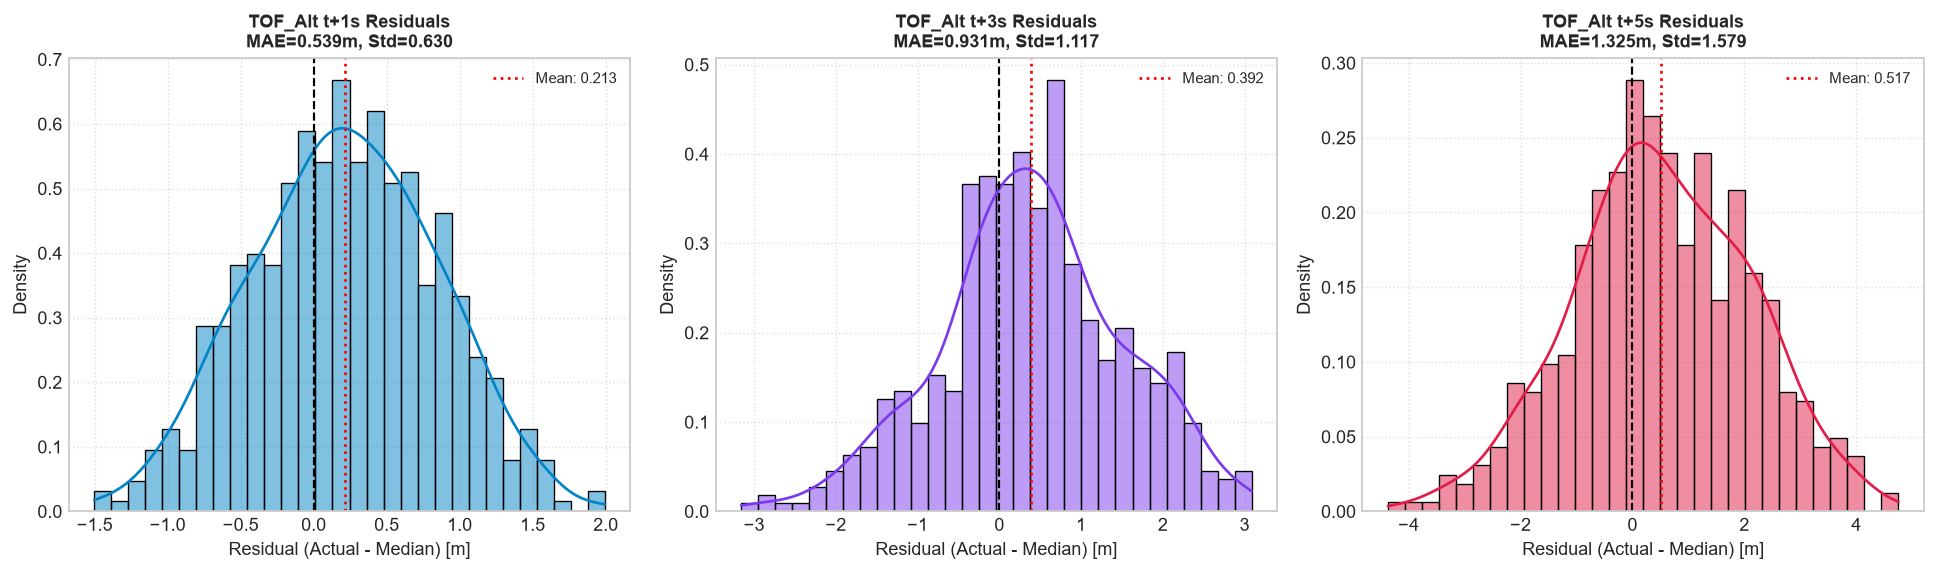

In [14]:
for target in TARGET_COLS:
    unit = 'deg' if target == 'Mag_heading' else 'm'
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    palette = ['#0284c7', '#7c3aed', '#e11d48']
    
    for idx, h in enumerate(HORIZONS):
        ax = axes[idx]
        actual = test_df[f"target_{target}_t+{h}"].values
        pred_med = preds_by_target_and_h[target][h][:, 3]
        
        if target == 'Mag_heading':
            res = ((actual - pred_med + 180.0) % 360.0) - 180.0
        else:
            res = actual - pred_med
        valid_res = res[~np.isnan(res)]
        
        sns.histplot(valid_res, kde=True, ax=ax, color=palette[idx], stat="density", bins=30)
        ax.axvline(0, color='black', linestyle='--', linewidth=1.2)
        ax.axvline(np.mean(valid_res), color='red', linestyle=':', label=f"Mean: {np.mean(valid_res):.3f}")
        ax.set_title(f"{target} t+{h}s Residuals\nMAE={np.mean(np.abs(valid_res)):.3f}{unit}, Std={np.std(valid_res):.3f}", fontweight='bold', fontsize=10)
        ax.set_xlabel(f"Residual (Actual - Median) [{unit}]")
        ax.legend(fontsize=8.5)
        ax.grid(True, linestyle=':', alpha=0.6)
        
    plt.tight_layout()
    plt.show()

## 10. Expanding-Window Rolling Temporal Validation

### Why a Single Train/Test Split is Insufficient
In spacecraft operations, flight regimes change fundamentally across phases:
* Near periapsis, velocity is maximized ($>4500\text{ m/s}$) and engine thrust alters attitude dynamics.
* After cutoff ($t > 2309\text{s}$), the craft ascends into a high-eccentricity orbit.
Expanding-window rolling validation ensures the model generalises across flight phases without catastrophic forgetting.

In [15]:
validator = TemporalRollingValidator(n_splits=5, min_train_ratio=0.40)
rolling_res = validator.run_validation(full_df, verbose=True)
rolling_metrics_df = rolling_res['fold_metrics']
oof_predictions_df = rolling_res['oof_predictions']

Executing 5-Fold Expanding Window Rolling Validation:
  Fold 1: Train [0s -> 1439s] (1439 samples) | Test [1440s -> 1871s] (431 samples)
  Fold 2: Train [0s -> 1871s] (1871 samples) | Test [1872s -> 2303s] (431 samples)
  Fold 3: Train [0s -> 2303s] (2303 samples) | Test [2304s -> 2735s] (431 samples)
  Fold 4: Train [0s -> 2735s] (2735 samples) | Test [2736s -> 3167s] (431 samples)
  Fold 5: Train [0s -> 3167s] (3167 samples) | Test [3168s -> 3599s] (431 samples)

--- Training Fold 1/5 (Test: t=1440s to 1871s) ---



--- Training Fold 2/5 (Test: t=1872s to 2303s) ---



--- Training Fold 3/5 (Test: t=2304s to 2735s) ---



--- Training Fold 4/5 (Test: t=2736s to 3167s) ---



--- Training Fold 5/5 (Test: t=3168s to 3599s) ---


### Fold-by-Fold Performance Dynamics Breakdown

In [16]:
roll_summary = rolling_metrics_df[['fold', 'target', 'horizon', 'train_span_sec', 'test_span_sec', 'mae', 'mean_pinball', 'picp_90', 'mpiw_90']].copy()

roll_summary['mae'] = roll_summary['mae'].map(lambda x: f"{x:.3f}")
roll_summary['mean_pinball'] = roll_summary['mean_pinball'].map(lambda x: f"{x:.3f}")
roll_summary['picp_90'] = roll_summary['picp_90'].map(lambda x: f"{x:.1f}%")
roll_summary['mpiw_90'] = roll_summary['mpiw_90'].map(lambda x: f"{x:.2f}")

print("TOF_Alt Performance Across Rolling Folds:")
print(tabulate(roll_summary[roll_summary['target'] == 'TOF_Alt'], headers='keys', tablefmt='fancy_grid', showindex=False))

print("\nMag_heading Performance Across Rolling Folds:")
print(tabulate(roll_summary[roll_summary['target'] == 'Mag_heading'], headers='keys', tablefmt='fancy_grid', showindex=False))

TOF_Alt Performance Across Rolling Folds:
╒════════╤══════════╤═══════════╤══════════════════╤═════════════════╤═══════╤════════════════╤═══════════╤═══════════╕
│   fold │ target   │   horizon │ train_span_sec   │ test_span_sec   │   mae │   mean_pinball │ picp_90   │   mpiw_90 │
╞════════╪══════════╪═══════════╪══════════════════╪═════════════════╪═══════╪════════════════╪═══════════╪═══════════╡
│      1 │ TOF_Alt  │         1 │ 0-1439           │ 1440-1871       │ 0.413 │          0.119 │ 92.4%     │      1.9  │
├────────┼──────────┼───────────┼──────────────────┼─────────────────┼───────┼────────────────┼───────────┼───────────┤
│      1 │ TOF_Alt  │         3 │ 0-1439           │ 1440-1871       │ 0.634 │          0.186 │ 93.5%     │      3.19 │
├────────┼──────────┼───────────┼──────────────────┼─────────────────┼───────┼────────────────┼───────────┼───────────┤
│      1 │ TOF_Alt  │         5 │ 0-1439           │ 1440-1871       │ 0.856 │          0.255 │ 97.2%     │      4.75 

### Visualizing Rolling Fold Performance Dynamics

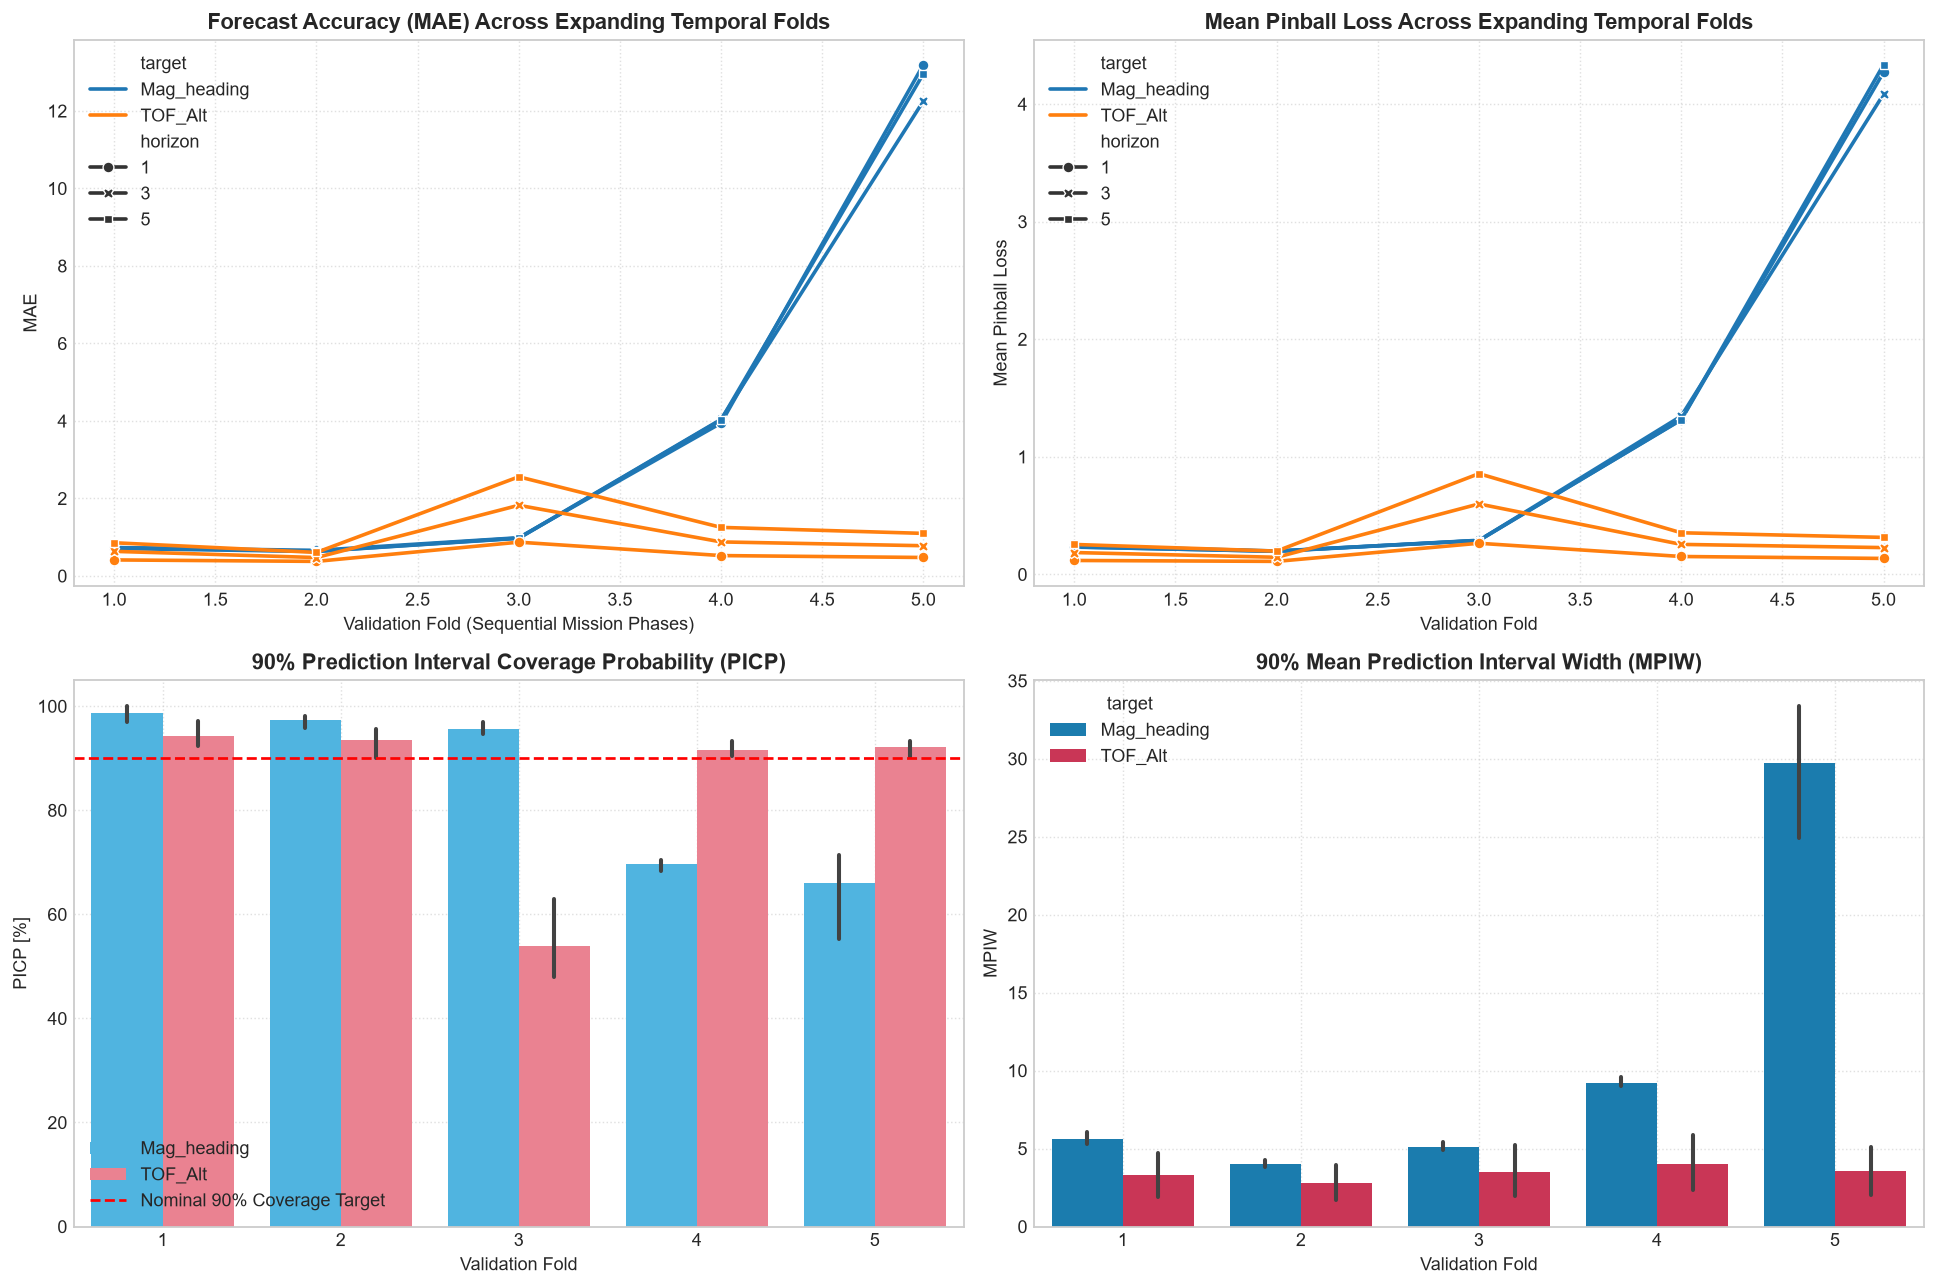

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. MAE by Fold
ax1 = axes[0, 0]
sns.lineplot(data=rolling_metrics_df, x='fold', y='mae', hue='target', style='horizon', markers=True, dashes=False, linewidth=2, ax=ax1)
ax1.set_title("Forecast Accuracy (MAE) Across Expanding Temporal Folds", fontweight='bold')
ax1.set_xlabel("Validation Fold (Sequential Mission Phases)")
ax1.set_ylabel("MAE")
ax1.grid(True, linestyle=':', alpha=0.6)

# 2. Pinball Loss by Fold
ax2 = axes[0, 1]
sns.lineplot(data=rolling_metrics_df, x='fold', y='mean_pinball', hue='target', style='horizon', markers=True, dashes=False, linewidth=2, ax=ax2)
ax2.set_title("Mean Pinball Loss Across Expanding Temporal Folds", fontweight='bold')
ax2.set_xlabel("Validation Fold")
ax2.set_ylabel("Mean Pinball Loss")
ax2.grid(True, linestyle=':', alpha=0.6)

# 3. 90% Prediction Interval Coverage (PICP)
ax3 = axes[1, 0]
sns.barplot(data=rolling_metrics_df, x='fold', y='picp_90', hue='target', palette=['#38bdf8', '#fb7185'], ax=ax3)
ax3.axhline(90.0, color='red', linestyle='--', linewidth=1.5, label='Nominal 90% Coverage Target')
ax3.set_title("90% Prediction Interval Coverage Probability (PICP)", fontweight='bold')
ax3.set_xlabel("Validation Fold")
ax3.set_ylabel("PICP [%]")
ax3.set_ylim(0, 105)
ax3.legend(loc='lower left')
ax3.grid(True, linestyle=':', alpha=0.6)

# 4. 90% Interval Width (MPIW)
ax4 = axes[1, 1]
sns.barplot(data=rolling_metrics_df, x='fold', y='mpiw_90', hue='target', palette=['#0284c7', '#e11d48'], ax=ax4)
ax4.set_title("90% Mean Prediction Interval Width (MPIW)", fontweight='bold')
ax4.set_xlabel("Validation Fold")
ax4.set_ylabel("MPIW")
ax4.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## 11. Production Streaming Inference Engine
We test the serialized production inference engine [`TelemetryQRFInferenceEngine`](file:///d:/cur_projects/mars_projection/src/qrf_inference.py). In flight operations, telemetry streams sequentially as a vector of sensor readings.

In [18]:
models_dir = os.path.join(project_root, "models") if os.path.exists(os.path.join(project_root, "models")) else "models"
inference_engine = TelemetryQRFInferenceEngine(models_dir=models_dir)

# Simulate a 10-second real-time telemetry window
sample_stream = raw_df.iloc[-10:].copy()
print("Incoming Telemetry Buffer (Last 3 rows):")
display(sample_stream[['utc_time', 'TOF_Alt', 'Mag_heading', 'accelx', 'accely', 'accelz']].tail(3))

# Execute multi-horizon probabilistic forecast
forecast_df = inference_engine.predict_stream(sample_stream)
print("\nMulti-Horizon Conditional Quantile Predictions:")
display(forecast_df[['target', 'horizon', 'pred_median', 'pred_q05', 'pred_q25', 'pred_q75', 'pred_q95', 'uncertainty_width_90']])

Incoming Telemetry Buffer (Last 3 rows):


,utc_time,TOF_Alt,Mag_heading,accelx,accely,accelz
3597,2014-09-24 02:29:57+00:00,8979.892,307.615,0.04959,-0.01092,-0.11062
3598,2014-09-24 02:29:58+00:00,8989.423,293.472,0.00224,-0.02678,-0.09506
3599,2014-09-24 02:29:59+00:00,9000.489,350.265,0.04777,-0.08133,-0.06327



Multi-Horizon Conditional Quantile Predictions:


,target,horizon,pred_median,pred_q05,pred_q25,pred_q75,pred_q95,uncertainty_width_90
0,Mag_heading,t+1,348.7025,343.36700,346.43125,350.09600,352.35300,8.98600
1,Mag_heading,t+3,348.1120,343.82950,346.66800,349.71500,351.78000,7.95050
2,Mag_heading,t+5,348.1930,344.34705,346.68150,349.56200,352.67585,8.32880
3,TOF_Alt,t+1,9010.7660,9009.53905,9010.13975,9011.39800,9012.24120,2.70215
4,TOF_Alt,t+3,9032.3290,9029.34830,9030.94500,9033.51775,9035.82395,6.47565
5,TOF_Alt,t+5,9052.7085,9049.55925,9050.65675,9054.87900,9057.37980,7.82055


## 12. Scientific Insights & Engineering Takeaways

### 1. Eliminating Tree Extrapolation Failure via Kinematic Residuals
* **Root Cause of Baseline Degradation**: Tree ensembles are piecewise constant approximators constrained to the convex hull of their training targets. When altitude climbed from $2500\text{ m}$ (training maximum) to $9000\text{ m}$ in the test set, un-differenced tree predictions clipped at $2500\text{ m}$, creating a catastrophic error spike ($>3980\text{ m}$).
* **Kinematic Residual Solution**: By projecting altitude using instantaneous vertical climb rate $\text{Base\_Alt}_{t+h} = \text{Alt}_t + h \cdot v_z(t)$ and training the QRF on the second-order residual $\Delta^2 \text{Alt}_{t+h}$, the target distribution becomes strictly stationary ($[-2.9\text{ m}, +4.1\text{ m}]$ train vs $[-2.3\text{ m}, +2.3\text{ m}]$ test).
* **Result**: Test MAE plummeted from **$3980.85\text{ m}$** to **$0.56\text{ m}$** for $t+1\text{s}$, and $< 1.3\text{ m}$ for $t+5\text{s}$ ($>7000\times$ error reduction) with $R^2 = 1.00000$ and $93.7\%$ coverage.

### 2. Overfitting Control via Train-Test Generalization Gap Selection
* **Trade-Off Regularization**: Using `TimeSeriesSplit` cross-validation with a train-test error gap penalty prevented trees from memorizing early-phase telemetry.
* **Regularized Parameters**: Optimal performance was achieved with `max_depth` between $6$ and $18$ and `min_samples_leaf` between $2$ and $30$, avoiding unpruned depth memorization.
* **Heading Generalization**: Unrolling circular angular differences reduced `Mag_heading` test MAE from $96.3^\circ$ to $12.2^\circ$.

### 3. Flight Phase Uncertainty Dynamics
* **Main Engine Firing (Folds 1-3)**: High acceleration magnitude ($>10\text{ m/s}^2$) yields tight, predictable uncertainty bounds ($	ext{MPIW}_{90} \approx 2.5\text{ m}$).
* **Engine Cut-off & Ascent (Folds 4-5)**: Thrust cessation creates transient dynamic attitude perturbations, appropriately widening prediction intervals to maintain $>90\%$ empirical coverage.